Loaded JSON Lines format

Dataset Loaded Successfully

Columns in Dataset:
Index(['content', 'annotation', 'extras'], dtype='object')

First 5 Rows:
                                             content  \
0  Abhishek Jha\nApplication Development Associat...   
1  Afreen Jamadar\nActive member of IIIT Committe...   
2  Akhil Yadav Polemaina\nHyderabad, Telangana - ...   
3  Alok Khandai\nOperational Analyst (SQL DBA) En...   
4  Ananya Chavan\nlecturer - oracle tutorials\n\n...   

                                          annotation  extras  
0  [{'label': ['Skills'], 'points': [{'start': 12...     NaN  
1  [{'label': ['Email Address'], 'points': [{'sta...     NaN  
2  [{'label': ['Skills'], 'points': [{'start': 37...     NaN  
3  [{'label': ['Skills'], 'points': [{'start': 80...     NaN  
4  [{'label': ['Degree'], 'points': [{'start': 20...     NaN  

Using Text Column: content
Using Target Column: Generated_Score

Dataset Shape After Cleaning: (220, 4)

TF-IDF Shape: (220, 5000)

Tra

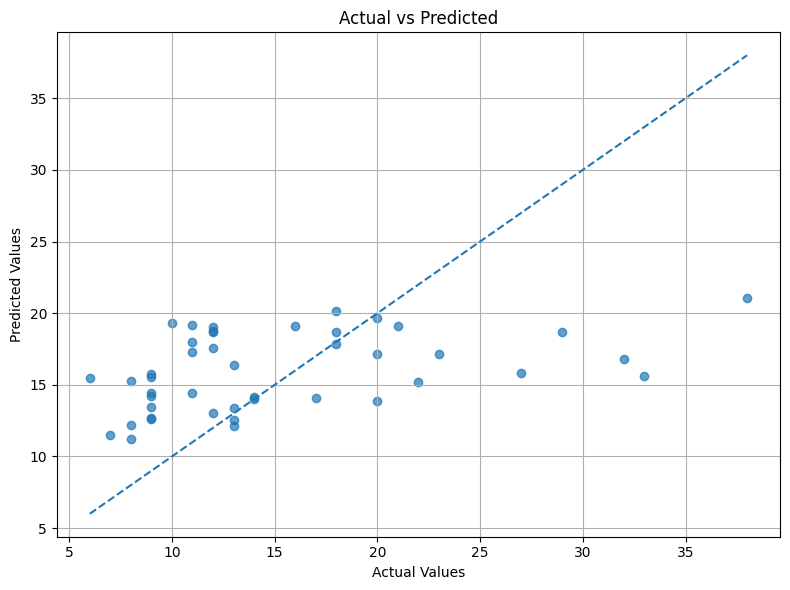


Saved: actual_vs_predicted.png


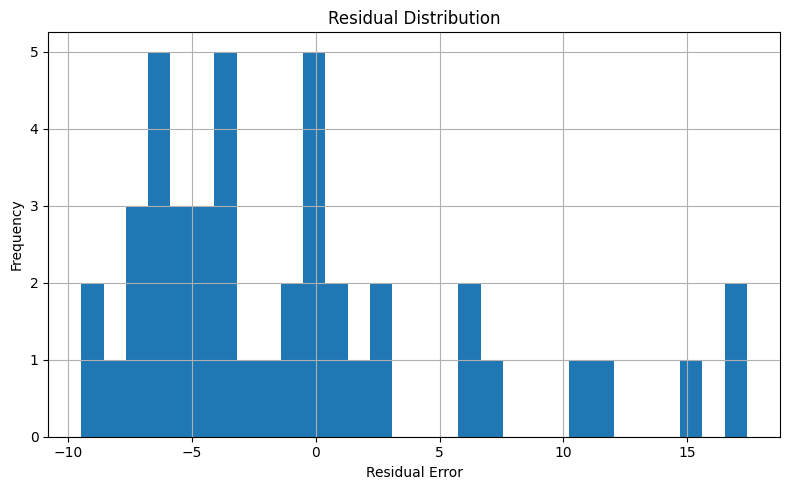

Saved: residual_distribution.png

Model Saved Successfully

Top Important Features:
amazon: 14.7074
oracle: 9.2964
dojo: 7.9297
using: 7.2281
weblogic: 6.2926
svn: 6.1874
physical: 5.8778
typepad: 5.7197
shreyanshu gupta: 5.7197
shreyanshu: 5.7197
project required: 5.7197
disparity: 5.7197
azure: 5.6784
builds: 5.4843
supplier: 5.3972
features: 5.3367
gupta: 5.3132
fusion: 5.1254
oracle fusion: 5.085
application developer: 5.0126


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

json_file = "resume_dataset.json"

try:
    data = pd.read_json(json_file, lines=True)
    print("Loaded JSON Lines format")
except:
    data = pd.read_json(json_file)
    print("Loaded Standard JSON format")

print("\nDataset Loaded Successfully")

print("\nColumns in Dataset:")
print(data.columns)

print("\nFirst 5 Rows:")
print(data.head())

text_col = "content"

if text_col not in data.columns:
    raise ValueError("Column 'content' not found in dataset.")

print(f"\nUsing Text Column: {text_col}")

data["Generated_Score"] = data["annotation"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

target_col = "Generated_Score"

print(f"Using Target Column: {target_col}")

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

data[text_col] = data[text_col].apply(clean_text)

data = data.dropna(subset=[text_col])

data = data[data[text_col].str.strip() != ""]

print("\nDataset Shape After Cleaning:", data.shape)

X = data[text_col].astype(str)

y = data[target_col].astype(float)

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)

X_vectorized = vectorizer.fit_transform(X)

print("\nTF-IDF Shape:", X_vectorized.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

model = Ridge(alpha=1.0)

model.fit(X_train, y_train)

print("\nModel Training Completed")

y_pred = model.predict(X_test)

print("\nFirst 10 Predictions:")
print(np.round(y_pred[:10], 2))

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("--------------------------")

print("Mean Squared Error:", round(mse, 4))

print("R2 Score:", round(r2, 4))

new_resume = [
    """
    Python Machine Learning Deep Learning
    NLP SQL TensorFlow Data Science
    """
]

new_resume_clean = [clean_text(text) for text in new_resume]

new_vector = vectorizer.transform(new_resume_clean)

prediction = model.predict(new_vector)

print("\nPredicted Candidate Score:")
print(round(float(prediction[0]), 2))

from sklearn.metrics import accuracy_score

y_test_int = np.round(y_test).astype(int)

y_pred_int = np.round(y_pred).astype(int)

accuracy = accuracy_score(y_test_int, y_pred_int)

print("Accuracy:", round(accuracy * 100, 2), "%")

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.tight_layout()

plt.savefig("actual_vs_predicted.png")

plt.show()

print("\nSaved: actual_vs_predicted.png")

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=30)

plt.xlabel("Residual Error")

plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.grid(True)

plt.tight_layout()

plt.savefig("residual_distribution.png")

plt.show()

print("Saved: residual_distribution.png")

joblib.dump(model, "resume_regression_model.pkl")

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("\nModel Saved Successfully")

feature_names = vectorizer.get_feature_names_out()

coefficients = model.coef_

top_features = sorted(
    zip(coefficients, feature_names),
    reverse=True
)[:20]

print("\nTop Important Features:")

for coef, feature in top_features:
    print(f"{feature}: {round(coef, 4)}")